# Plant Disease / Pest Damage Detection from Leaf Imagery — PlantVillage
### Own ML Project — Exam 3

**Task:** multi-class classification — given a close-range leaf image, is the
plant healthy, and if not, which disease/pest-damage pattern is present?

**Why this is the project's 3rd dataset pivot (see CLAUDE.md for full history):**
IP102 (macro insect photography) turned out to be unrealistic for any real
drone altitude. Agriculture-Vision fixed the realism problem but drifted the
topic away from pests entirely (generic field patterns: weeds, water, drydown)
and required a 20GB download. PlantVillage is the fix for both: disease/pest
damage lesions are large enough (leaf-scale, not insect-scale) to be visible
from CLOSE-RANGE drone imaging -- which is a real, existing practice (orchard
and vineyard row-scanning drones fly a few meters from canopy, not 10-50m up)
-- and the dataset is ~2GB, not 20GB.

**Constraint:** "pure ML" — no hand-crafted lesion-shape features. The model
learns directly from raw (resized, normalized) pixels.

**Report section map** (see `ML_Fundamentals_Reference.md` for formulas
backing every choice below):

| Notebook section | Report section |
|---|---|
| 1. Data | Problem relevance + Data choice |
| 2. Class selection & preprocessing | Model setup justification (part 1) |
| 3. Split & imbalance handling | Model setup justification (part 2) |
| 4. Baseline (Logistic Regression) | Baselines |
| 5. Main model (2D-CNN) | Model setup justification (part 3) |
| 6. Comparison | Evaluation |
| 7. Failure case analysis | Evaluation (failure cases) |
| 8. Interpretation (Grad-CAM) | Interpretation |
| 9. Conclusion | "Why this data/setup were right (or not)" |


In [1]:
import os, sys

PROJECT_ROOT = os.getcwd()
if os.path.basename(PROJECT_ROOT) == "notebooks":
    PROJECT_ROOT = os.path.abspath(os.path.join(PROJECT_ROOT, os.pardir))
sys.path.insert(0, PROJECT_ROOT)

DATA_DIR = os.path.join(PROJECT_ROOT, "data")
FIG_DIR = os.path.join(PROJECT_ROOT, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from src.utils import set_seed, get_device
from src.preprocessing import index_dataset, select_top_classes
from src.dataset import build_label_mapping, stratified_split, compute_class_weights, build_dataloaders
from src.models import LogisticRegressionBaseline, CNN2D
from src.train import train_model
from src.evaluate import get_predictions, print_report, plot_confusion_matrix, compare_models
from src.interpret import compute_gradcam, plot_gradcam_overlay

set_seed(42)
device = get_device()
print(f"Using device: {device}")


Using device: cpu


## 1. Data

**Source:** [PlantVillage](https://github.com/spMohanty/PlantVillage-Dataset)
(Hughes & Salathé, 2015) — ~54,300 leaf images across 38 classes (14 crop
species x healthy/diseased combinations), captured under controlled
conditions with a static background.

**Why this dataset:** widely used, citable academic benchmark; disease and
pest-damage symptoms (lesions, blight, mold, discoloration) are large enough
on a leaf to be visible from realistic CLOSE-RANGE drone imaging distances —
unlike individual insects, which are sub-pixel from any normal survey
altitude. Also ~2GB, a manageable download.

**Real-world relevance:** orchard, vineyard, and greenhouse drones already
fly close to canopy (a few meters, not 10-50m) specifically for this kind of
leaf-level health inspection — this is a real, existing precision-agriculture
practice, not a hypothetical. A classifier like this is the recognition
module for that kind of close-range crop-scouting pass: flag diseased/pest-
damaged plants early, before symptoms spread, enabling targeted treatment
instead of blanket spraying.

**Known limitations (state these explicitly in the report):**
- Images were captured under controlled conditions (uniform background,
  consistent framing) — real drone-mounted camera footage would have
  variable lighting, motion blur, cluttered backgrounds, partial leaf
  occlusion. This is a real domain gap, smaller than IP102's (leaf-scale
  symptoms are still visible at this scale, unlike individual insects) but
  worth stating plainly rather than glossing over.
- "Disease/pest damage" is broader than "pests" alone — some PlantVillage
  classes are fungal/bacterial/viral diseases rather than insect damage.
  Framed honestly, this project is about crop health symptom detection in
  general, of which pest damage is one cause among several.
- Class balance varies significantly by crop/disease combination — handled
  via class-weighted loss (Section 3).

**Data placement:** download PlantVillage (Kaggle mirrors work fine) and
place the class folders directly under `data/` — i.e. `data/<ClassName>/*.jpg`
for every class (e.g. `data/Tomato___Late_blight/`, `data/Potato___healthy/`).
`src/preprocessing.py::index_dataset()` auto-detects this layout.


In [2]:
df_all = index_dataset(DATA_DIR)
df_all["class_name"].value_counts()


Detected dataset format: A (ImageFolder-style directories). Found 41276 images across 15 classes.


class_name
Tomato__Tomato_YellowLeaf__Curl_Virus          6416
Tomato_Bacterial_spot                          4254
Tomato_Late_blight                             3818
Tomato_Septoria_leaf_spot                      3542
Tomato_Spider_mites_Two_spotted_spider_mite    3352
Tomato_healthy                                 3182
Pepper__bell___healthy                         2956
Tomato__Target_Spot                            2808
Potato___Early_blight                          2000
Potato___Late_blight                           2000
Tomato_Early_blight                            2000
Pepper__bell___Bacterial_spot                  1994
Tomato_Leaf_Mold                               1904
Tomato__Tomato_mosaic_virus                     746
Potato___healthy                                304
Name: count, dtype: int64

## 2. Class Selection & Preprocessing

**Class selection:** PlantVillage's full 38-class taxonomy spans 14 crop
species. For a focused, tractable project, we keep only the N
most-represented classes (default N=15) with at least `min_per_class` images
— an explicit scoping decision, same spirit as the IP102 project's top-N
selection. Consider restricting to a single crop's disease classes (e.g. all
Tomato___* classes) for an even more focused comparison — adjust the filter
below if you'd like that framing instead.

**Preprocessing (generic, no hand-crafted lesion features):**
- Resize every image to 128x128
- Normalize channel-wise (ImageNet mean/std)
- **Training split only:** random horizontal flip, random rotation (±15° —
  a leaf has a natural up/down orientation, unlike the aerial imagery
  explored in this project's earlier Agriculture-Vision attempt, so we don't
  use full 360° rotation here), color jitter


In [3]:
N_CLASSES = 15
MIN_PER_CLASS = 200

df = select_top_classes(df_all, n_classes=N_CLASSES, min_per_class=MIN_PER_CLASS)
class_names, name_to_idx = build_label_mapping(df)
df["label_idx"] = df["class_name"].map(name_to_idx)

print(f"\nFinal dataset: {len(df)} images across {len(class_names)} classes")
df["class_name"].value_counts()


Selected top 15 classes (of 15 total):
  Tomato__Tomato_YellowLeaf__Curl_Virus: 6416 images
  Tomato_Bacterial_spot: 4254 images
  Tomato_Late_blight: 3818 images
  Tomato_Septoria_leaf_spot: 3542 images
  Tomato_Spider_mites_Two_spotted_spider_mite: 3352 images
  Tomato_healthy: 3182 images
  Pepper__bell___healthy: 2956 images
  Tomato__Target_Spot: 2808 images
  Potato___Early_blight: 2000 images
  Potato___Late_blight: 2000 images
  Tomato_Early_blight: 2000 images
  Pepper__bell___Bacterial_spot: 1994 images
  Tomato_Leaf_Mold: 1904 images
  Tomato__Tomato_mosaic_virus: 746 images
  Potato___healthy: 304 images

Final dataset: 41276 images across 15 classes


class_name
Tomato__Tomato_YellowLeaf__Curl_Virus          6416
Tomato_Bacterial_spot                          4254
Tomato_Late_blight                             3818
Tomato_Septoria_leaf_spot                      3542
Tomato_Spider_mites_Two_spotted_spider_mite    3352
Tomato_healthy                                 3182
Pepper__bell___healthy                         2956
Tomato__Target_Spot                            2808
Potato___Early_blight                          2000
Potato___Late_blight                           2000
Tomato_Early_blight                            2000
Pepper__bell___Bacterial_spot                  1994
Tomato_Leaf_Mold                               1904
Tomato__Tomato_mosaic_virus                     746
Potato___healthy                                304
Name: count, dtype: int64

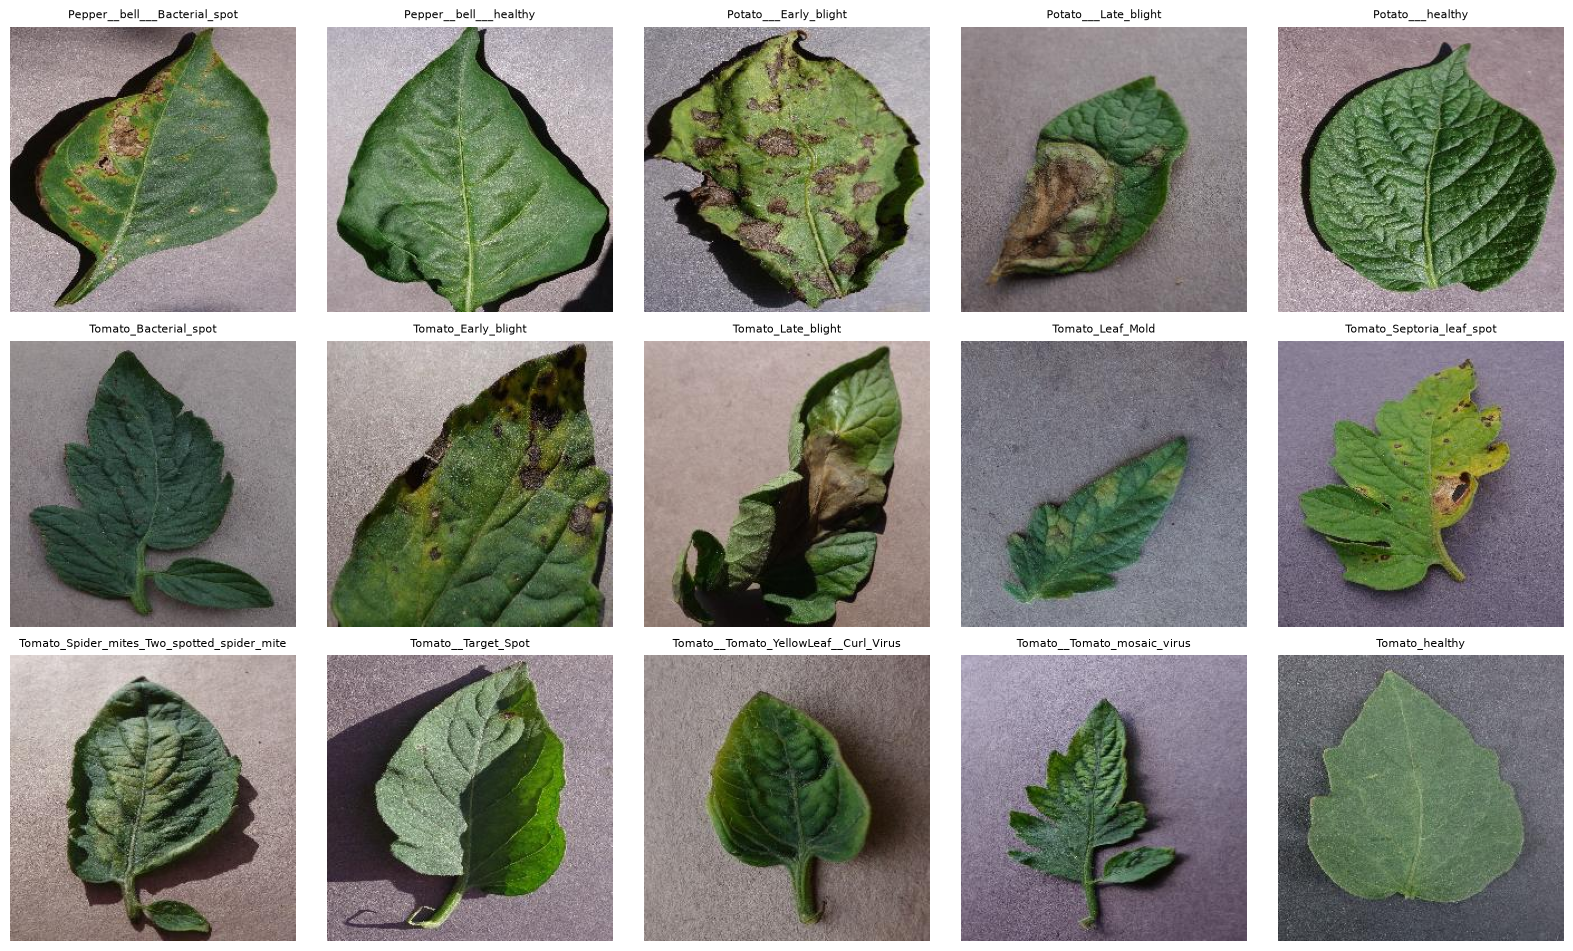

In [4]:
# Quick look: one example image per class
from PIL import Image

n_cols = 5
n_rows = (len(class_names) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.2 * n_rows))
axes = axes.flatten()
for i, cname in enumerate(class_names):
    example_path = df[df["class_name"] == cname]["path"].iloc[0]
    img = Image.open(example_path).convert("RGB")
    axes[i].imshow(img)
    axes[i].set_title(cname, fontsize=8)
    axes[i].axis("off")
for j in range(len(class_names), len(axes)):
    axes[j].axis("off")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "class_examples.png"), dpi=150)
plt.show()


## 3. Train / Validation / Test Split & Class Imbalance Handling

- **Stratified 70/15/15 split** by class.
- **Class-weighted loss** (inverse frequency, `CrossEntropyLoss(weight=...)`)
  to handle the uneven per-class image counts.
- **Augmentation applied to the training split only.**


In [5]:
df_train, df_val, df_test = stratified_split(df, seed=42)
print(f"train={len(df_train)} | val={len(df_val)} | test={len(df_test)}")

n_classes = len(class_names)
class_weights = compute_class_weights(df_train["label_idx"].tolist(), n_classes)
print("Class weights:", class_weights)

train_loader, val_loader, test_loader = build_dataloaders(df_train, df_val, df_test, batch_size=32)


train=28892 | val=6192 | test=6192
Class weights: tensor([1.3798, 0.9309, 1.3758, 1.3758, 9.0855, 0.6468, 1.3758, 0.7209, 1.4460,
        0.7767, 0.8210, 0.9797, 0.4289, 3.6899, 0.8645])


## 4. Baseline — Logistic Regression

Flattened raw (resized, normalized) image pixels straight into one linear
layer per class. No convolution, no spatial structure exploited —
deliberately weak reference point for the CNN to beat.


Epoch   1 | train_loss=13.1384 acc=0.389 | val_loss=12.0269 acc=0.478
Epoch   2 | train_loss=13.2566 acc=0.461 | val_loss=14.7794 acc=0.470
Epoch   3 | train_loss=13.1280 acc=0.486 | val_loss=16.3711 acc=0.447
Epoch   4 | train_loss=12.9939 acc=0.499 | val_loss=17.1787 acc=0.493
Epoch   5 | train_loss=13.3185 acc=0.505 | val_loss=13.6133 acc=0.522
Epoch   6 | train_loss=13.4930 acc=0.519 | val_loss=21.2446 acc=0.460
Epoch   7 | train_loss=13.4959 acc=0.523 | val_loss=18.3164 acc=0.452
Early stopping at epoch 7 (no improvement for 6 epochs).
--- Baseline (Logistic Regression) : classification report ---
Accuracy: 0.477 | Macro-F1: 0.427
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot      0.420     0.368     0.392       299
                     Pepper__bell___healthy      0.695     0.350     0.465       443
                      Potato___Early_blight      0.806     0.637     0.711       300
               

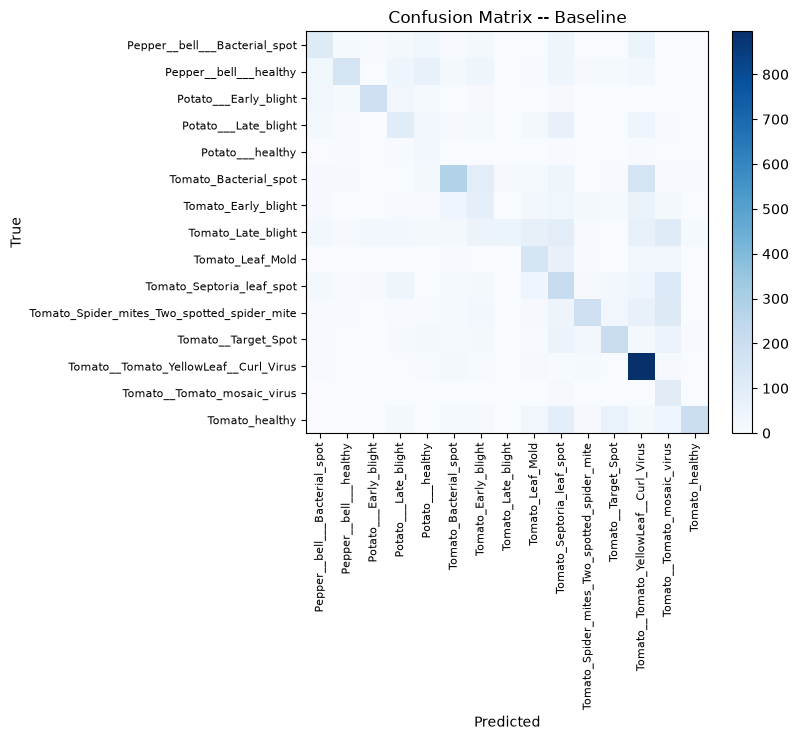

In [6]:
baseline = LogisticRegressionBaseline(n_classes, img_size=128)
baseline, baseline_history = train_model(
    baseline, train_loader, val_loader, device,
    epochs=30, lr=1e-3, class_weights=class_weights, patience=6, verbose=True,
)

y_true_base, y_pred_base = get_predictions(baseline, test_loader, device)
print_report(y_true_base, y_pred_base, class_names, "Baseline (Logistic Regression)")
plot_confusion_matrix(y_true_base, y_pred_base, class_names, "Baseline",
                       save_path=os.path.join(FIG_DIR, "cm_baseline.png"))
plt.show()


## 5. Main model — 2D-CNN (built from scratch)

Four convolutional blocks (Conv2d → BatchNorm → ReLU → MaxPool, channels
16→32→64→128), global average pooling, dropout-regularized dense head.
Built from scratch, not a pretrained backbone.

- **Global average pooling** — manageable parameter count AND the
  architecture Grad-CAM needs (Section 8).
- **Dropout + BatchNorm** for regularization (§8 of the reference doc).
- **Loss:** categorical cross-entropy (`CrossEntropyLoss`) — §1.2.
- **Optimizer:** Adam — extension of §2.3's mini-batch GD, not named in the
  course slides, worth flagging as such in the report.


In [ ]:
cnn = CNN2D(n_classes, dropout=0.3)
cnn, cnn_history = train_model(
    cnn, train_loader, val_loader, device,
    epochs=30, lr=1e-3, class_weights=class_weights, patience=6, verbose=True,
)

y_true_cnn, y_pred_cnn = get_predictions(cnn, test_loader, device)
print_report(y_true_cnn, y_pred_cnn, class_names, "CNN")
plot_confusion_matrix(y_true_cnn, y_pred_cnn, class_names, "CNN",
                       save_path=os.path.join(FIG_DIR, "cm_cnn.png"))
plt.show()


Epoch   1 | train_loss=1.5245 acc=0.496 | val_loss=0.8255 acc=0.725
Epoch   2 | train_loss=0.8789 acc=0.696 | val_loss=0.5920 acc=0.794
Epoch   3 | train_loss=0.7132 acc=0.755 | val_loss=0.3943 acc=0.877
Epoch   4 | train_loss=0.6198 acc=0.789 | val_loss=0.3060 acc=0.892


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(cnn_history["train_loss"], label="train")
axes[0].plot(cnn_history["val_loss"], label="val")
axes[0].set_title("CNN loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(cnn_history["train_acc"], label="train")
axes[1].plot(cnn_history["val_acc"], label="val")
axes[1].set_title("CNN accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "cnn_learning_curves.png"), dpi=150)
plt.show()


## 6. Baseline vs. CNN Comparison


In [ ]:
compare_models(
    {"Baseline": (y_true_base, y_pred_base), "CNN": (y_true_cnn, y_pred_cnn)},
    save_path=os.path.join(FIG_DIR, "model_comparison.png"),
)
plt.show()


## 7. Failure Case Analysis

Some disease pairs on the same crop look visually similar in early stages
(e.g. different blight types) -- inspect specific CNN errors to see whether
this drives most of the mistakes, or whether errors are scattered/random.


In [ ]:
from PIL import Image as PILImage

wrong_idx = np.where(y_true_cnn != y_pred_cnn)[0]
print(f"CNN misclassified {len(wrong_idx)} / {len(y_true_cnn)} test images")

n_show = min(4, len(wrong_idx))
if n_show > 0:
    fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 4))
    if n_show == 1:
        axes = [axes]
    for ax, idx in zip(axes, wrong_idx[:n_show]):
        img_path = df_test.iloc[idx]["path"]
        img = PILImage.open(img_path).convert("RGB")
        ax.imshow(img)
        ax.set_title(f"True: {class_names[y_true_cnn[idx]]}\nPred: {class_names[y_pred_cnn[idx]]}", fontsize=8)
        ax.axis("off")
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, "failure_cases.png"), dpi=150)
    plt.show()


## 8. Interpretation — Grad-CAM

Check whether the model's attention lands on the actual lesion/discolored
region of the leaf, not the healthy leaf tissue or background — this is the
core evidence for the Interpretation section, and the most legible Grad-CAM
result across every dataset explored in this project so far.


In [ ]:
correct_idx = np.where(y_true_cnn == y_pred_cnn)[0]
seen_classes = set()
example_indices = []
for idx in correct_idx:
    c = y_true_cnn[idx]
    cname = class_names[c]
    if c not in seen_classes and "healthy" not in cname:
        example_indices.append(idx)
        seen_classes.add(c)
    if len(example_indices) >= 4:
        break

for idx in example_indices:
    x_sample, y_sample = test_loader.dataset[idx]
    x_input = x_sample.unsqueeze(0)
    cam, pred_class, pred_prob = compute_gradcam(cnn, x_input, device)
    plot_gradcam_overlay(
        x_sample, cam, class_names[y_sample], class_names[pred_class], pred_prob,
        save_path=os.path.join(FIG_DIR, f"gradcam_{class_names[y_sample]}.png"),
    )
    plt.show()


## 9. Conclusion

*(Fill in after running on the real dataset — use the actual metrics from Section 6.)*

Prompts to answer here for the required "why this data and setup were the
right choice (or not)" conclusion:

- Did the CNN meaningfully beat the logistic regression baseline? By how
  much, on accuracy AND macro-F1?
- Did Grad-CAM show the model actually keying on the lesion/damage region?
- What did the misclassified examples in Section 7 have in common?
- PlantVillage's controlled-condition images are a smaller domain gap than
  IP102's macro insect photos were, but still not real drone footage --
  how much do you think that gap would matter in practice, now that you've
  seen the actual results?
- Looking back across all three dataset attempts (IP102 → Agriculture-Vision
  → PlantVillage) -- what would you do differently if starting the data
  search over, knowing what you know now about the realism/scope trade-offs?
